In [36]:
# install FRED api (Federal Reserve Bank at St Louis)
!pip install fredapi

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
import cvxpy as cp
from google.colab import userdata

inv = np.linalg.inv

start_date = '2016-05-17'
end_date = '2026-01-30'

szinek = ['black', 'gray', 'gold', 'darkblue', 'mediumseagreen']
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

# Értékpapírok adatbázis

[*********************100%***********************]  5 of 5 completed


Ticker,SPY,TLT,GLD,VNQ,UUP
Date,,,,,
2016-05-17,174.038422,99.944183,122.220001,56.239258,20.450605
2016-05-18,174.089355,98.521416,120.099998,55.358208,20.592625
2016-05-19,173.486191,98.947502,119.870003,54.739468,20.626040
2016-05-20,174.582123,99.023560,119.709999,55.176609,20.626040
2016-05-23,174.344238,99.244217,119.370003,55.183357,20.617685
...,...,...,...,...,...
2026-01-23,687.352783,86.957199,458.000000,89.582367,26.910000
2026-01-26,690.843262,87.372543,464.700012,89.463638,26.780001
2026-01-27,693.595764,86.828636,476.100006,89.433952,26.469999


<Figure size 640x480 with 0 Axes>

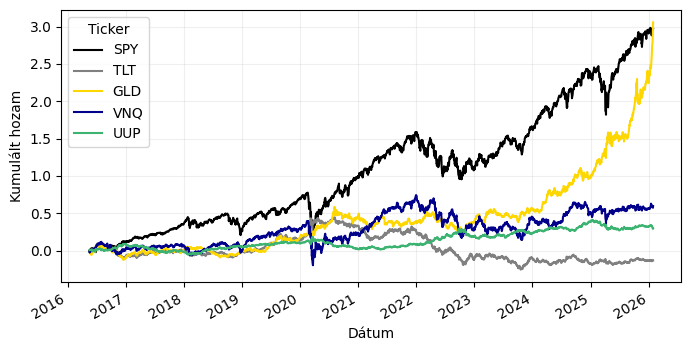

In [38]:
FRED_API_KEY = userdata.get('MY_FRED')
fred = Fred(api_key=FRED_API_KEY)

tickers = ['SPY', 'TLT', 'GLD', 'VNQ', 'UUP']
#SPY S&P500
#TLT állampapírok
#GLD arany
#VNQ ingatlanbefektetési alapok
#UUP dollár értéke, devizapiac

# Napi árfolyam adatok betöltése
price_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
price_df = price_data['Close']
price_df = price_df[tickers]

display(price_df)

# Hozamosítás
price_df = price_df.ffill().dropna()
price_df = price_df.pct_change()

# Kumulatív napi hozamok
cumulative_growth = (1 + price_df).cumprod() - 1

plt.figure()
cumulative_growth.plot(figsize=(8, 4), color = szinek)
plt.xlabel('Dátum')
plt.ylabel('Kumulált hozam')
plt.savefig('FRED_Kumulalt_tickers.pdf', bbox_inches='tight')
plt.show()
plt.close()

# Faktorok adatbázis
sorrend: CPI - FEDRATE - GDP

In [39]:
import requests
import io

# Inflation
url = 'https://raw.githubusercontent.com/siklerjulianna/TDK-MBL/main/Data_FRED/df_Inflation_data.csv'
response = requests.get(url)
df_Inflation_data = pd.read_csv(io.StringIO(response.text))
df_Inflation_data = df_Inflation_data.rename(columns ={'CPI - Actual':'CPI', 'CPI - Expectation':'CPI-exp','CPI_Var':'CPI-var' })

# Fedrate
url = 'https://raw.githubusercontent.com/siklerjulianna/TDK-MBL/main/Data_FRED/df_Fedrate_data.csv'
response = requests.get(url)
df_Fedrate_data = pd.read_csv(io.StringIO(response.text))
df_Fedrate_data = df_Fedrate_data.rename(columns ={'Fed rate - Actual':'Fed rate', 'Fed rate - Expectation':'Fed rate-exp','Fed_Var':'Fed rate-var' })

# GDP
url = 'https://raw.githubusercontent.com/siklerjulianna/TDK-MBL/main/Data_FRED/df_GDP_data.csv'
response = requests.get(url)
df_GDP_data = pd.read_csv(io.StringIO(response.text))
df_GDP_data = df_GDP_data.rename(columns ={'GDP - Actual':'dGDP', 'GDP - Expectation':'dGDP-exp','GDP_Var':'dGDP-var' })

display(df_Inflation_data)
display(df_Fedrate_data)
display(df_GDP_data)

,Date,CPI,CPI-exp,CPI-var
0,2013-09-17,0.180280,0.272673,0.110283
1,2013-09-18,0.180280,0.272673,0.110283
2,2013-09-19,0.180280,0.272673,0.110283
3,2013-09-20,0.180280,0.272673,0.110283
4,2013-09-23,0.180280,0.272673,0.110283
...,...,...,...,...
3001,2026-02-09,0.307355,0.134979,0.006535
3002,2026-02-10,0.307355,0.134979,0.006651
3003,2026-02-11,0.307355,0.134979,0.006866
3004,2026-02-12,0.307355,0.134979,0.006959


,Date,Fed rate,Fed rate-exp,Fed rate-var
0,2010-01-04,0.12,0.05,0.004900
1,2010-01-05,0.12,0.03,0.004900
2,2010-01-06,0.12,0.03,0.004900
3,2010-01-07,0.10,0.02,0.004900
4,2010-01-08,0.11,0.02,0.004900
...,...,...,...,...
4190,2026-01-26,3.64,3.77,0.023275
4191,2026-01-27,3.64,3.77,0.021678
4192,2026-01-28,3.64,3.76,0.020310
4193,2026-01-29,3.64,3.72,0.020310


,Date,dGDP,dGDP-exp,dGDP-var
0,2016-05-17,0.5,2.5338,1.137849
1,2016-05-18,0.5,2.5338,1.137849
2,2016-05-19,0.5,2.5338,1.137849
3,2016-05-20,0.5,2.5338,1.137849
4,2016-05-23,0.5,2.5338,1.137849
...,...,...,...,...
2559,2026-03-09,1.4,4.2373,4.296500
2560,2026-03-10,1.4,4.2373,4.296500
2561,2026-03-11,1.4,4.2373,4.296500
2562,2026-03-12,1.4,4.2373,4.296500


In [40]:
# Adattisztítás, adatok összefűzése
# Előkészítés
for df in [df_Inflation_data, df_Fedrate_data, df_GDP_data]:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
    elif df.index.name == 'Date':
        df.index = pd.to_datetime(df.index)

# Globális üzleti nap index
full_index = pd.date_range(start_date, end_date, freq='B')

# Összefűzés
macro_df = pd.concat([
    df_Inflation_data[~df_Inflation_data.index.duplicated(keep='last')],
    df_Fedrate_data[~df_Fedrate_data.index.duplicated(keep='last')],
    df_GDP_data[~df_GDP_data.index.duplicated(keep='last')]
], axis=1)


# Reindexelés és kitöltés
macro_df = macro_df.reindex(full_index).ffill()

# Kezdeti üres értékek kitöltése
macro_df.bfill(inplace=True)

macro_df.index.name = 'Date'
print(macro_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2534 entries, 2016-05-17 to 2026-01-30
Freq: B
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CPI           2534 non-null   float64
 1   CPI-exp       2534 non-null   float64
 2   CPI-var       2534 non-null   float64
 3   Fed rate      2534 non-null   float64
 4   Fed rate-exp  2534 non-null   float64
 5   Fed rate-var  2534 non-null   float64
 6   dGDP          2534 non-null   float64
 7   dGDP-exp      2534 non-null   float64
 8   dGDP-var      2534 non-null   float64
dtypes: float64(9)
memory usage: 198.0 KB
None


<Figure size 640x480 with 0 Axes>

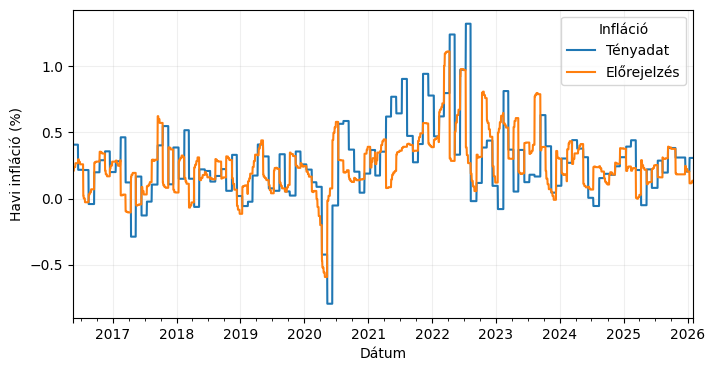

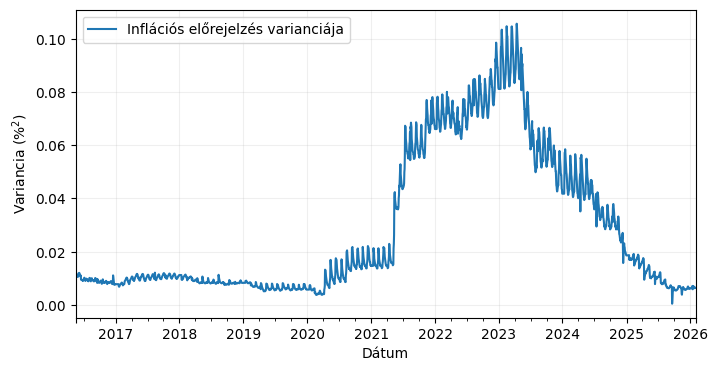

<Figure size 640x480 with 0 Axes>

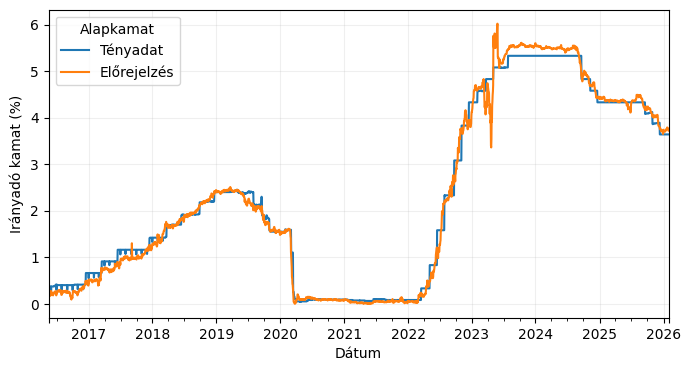

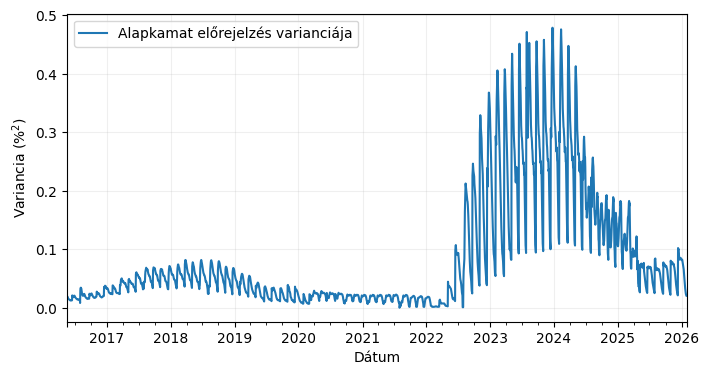

<Figure size 640x480 with 0 Axes>

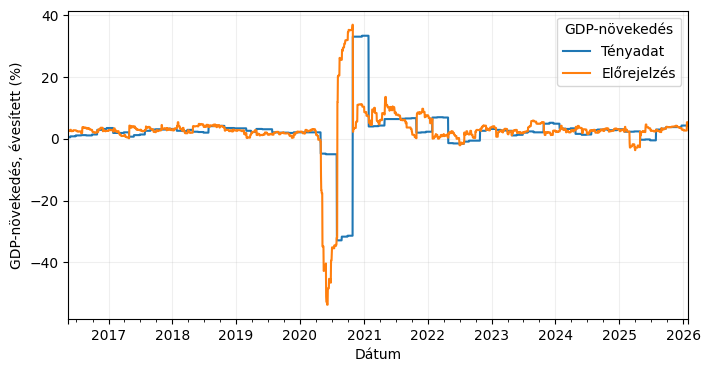

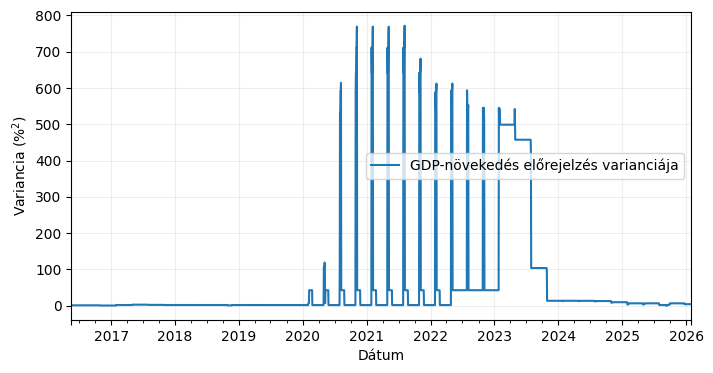

In [41]:
plt.figure()
macro_df[['CPI','CPI-exp']].plot(figsize=(8, 4))
plt.xlabel('Dátum')
plt.ylabel('Havi infláció (%)')
plt.legend(title = 'Infláció', labels = ['Tényadat','Előrejelzés'])
plt.savefig('Inflacio_teljes.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure()
macro_df['CPI-var'].plot(figsize=(8, 4))
plt.xlabel('Dátum')
plt.ylabel(r'Variancia (%$^2$)')
plt.legend(labels = ['Inflációs előrejelzés varianciája'])
plt.savefig('Inflacio_var_teljes.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure()
macro_df[['Fed rate','Fed rate-exp']].plot(figsize=(8, 4))
plt.xlabel('Dátum')
plt.ylabel('Irányadó kamat (%)')
plt.legend(title = 'Alapkamat', labels = ['Tényadat','Előrejelzés'])
plt.savefig('Alapkamat_teljes.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure()
macro_df['Fed rate-var'].plot(figsize=(8, 4))
plt.xlabel('Dátum')
plt.ylabel(r'Variancia (%$^2$)')
plt.legend(labels = ['Alapkamat előrejelzés varianciája'])
plt.savefig('Alapkamat_var_teljes.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure()
macro_df[['dGDP','dGDP-exp']].plot(figsize=(8, 4))
plt.xlabel('Dátum')
plt.ylabel('GDP-növekedés, évesített (%)')
plt.legend(title = 'GDP-növekedés', labels = ['Tényadat','Előrejelzés'])
plt.savefig('GDP_teljes.pdf', bbox_inches='tight')
plt.show()
plt.close()

plt.figure()
macro_df['dGDP-var'].plot(figsize=(8, 4))
plt.xlabel('Dátum')
plt.ylabel(r'Variancia (%$^2$)')
plt.legend(labels = ['GDP-növekedés előrejelzés varianciája'])
plt.savefig('GDP_var_teljes.pdf', bbox_inches='tight')
plt.show()
plt.close()


# FRED makrofaktorok: tényadat és előrejelzés

Értékpapírok és faktorok végső adatbázisa

In [42]:
combined_df = price_df.join(macro_df, how='left')
combined_df = combined_df.ffill().dropna()

display(combined_df)

,SPY,TLT,GLD,VNQ,UUP,CPI,CPI-exp,CPI-var,Fed rate,Fed rate-exp,Fed rate-var,dGDP,dGDP-exp,dGDP-var
Date,,,,,,,,,,,,,,
2016-05-18,0.000293,-0.014236,-0.017346,-0.015666,0.006945,0.407700,0.209917,0.012010,0.37,0.25,0.019569,0.5,2.5338,1.137849
2016-05-19,-0.003465,0.004325,-0.001915,-0.011177,0.001623,0.407700,0.209917,0.012055,0.37,0.25,0.019142,0.5,2.5338,1.137849
2016-05-20,0.006317,0.000769,-0.001335,0.007986,0.000000,0.407700,0.209917,0.011905,0.37,0.26,0.018579,0.5,2.5338,1.137849
2016-05-23,-0.001363,0.002228,-0.002840,0.000122,-0.000405,0.407700,0.209917,0.011225,0.37,0.26,0.017184,0.5,2.5338,1.137849
2016-05-24,0.012962,-0.004447,-0.017341,0.012431,0.003242,0.407700,0.237982,0.010907,0.37,0.28,0.016223,0.5,2.5338,1.137849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-23,0.000363,0.002737,0.013745,0.001992,-0.008840,0.307355,0.120797,0.006312,3.64,3.78,0.026319,4.4,5.3721,4.296500
2026-01-26,0.005078,0.004776,0.014629,-0.001325,-0.004831,0.307355,0.120797,0.006544,3.64,3.77,0.023275,4.4,5.3988,4.296500
2026-01-27,0.003984,-0.006225,0.024532,-0.000332,-0.011576,0.307355,0.120797,0.006457,3.64,3.77,0.021678,4.4,5.3988,4.296500


Ábrázolás kétéves bontásban

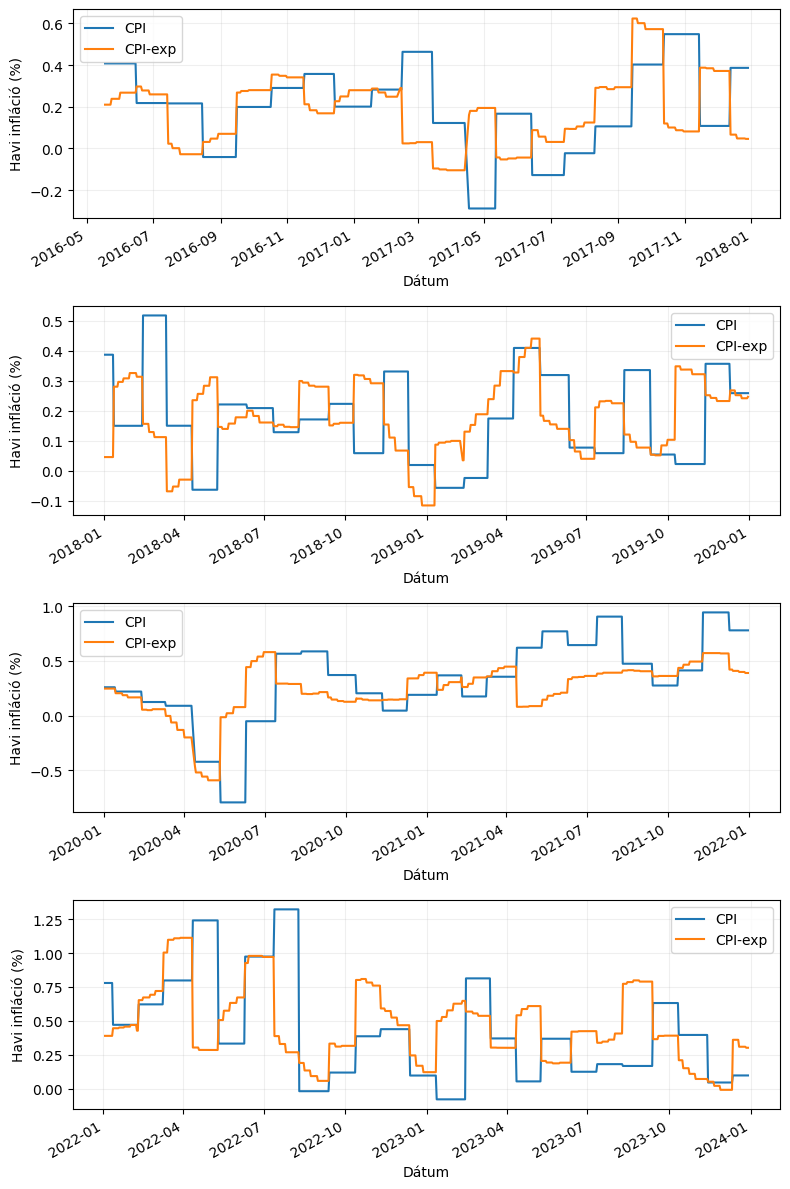

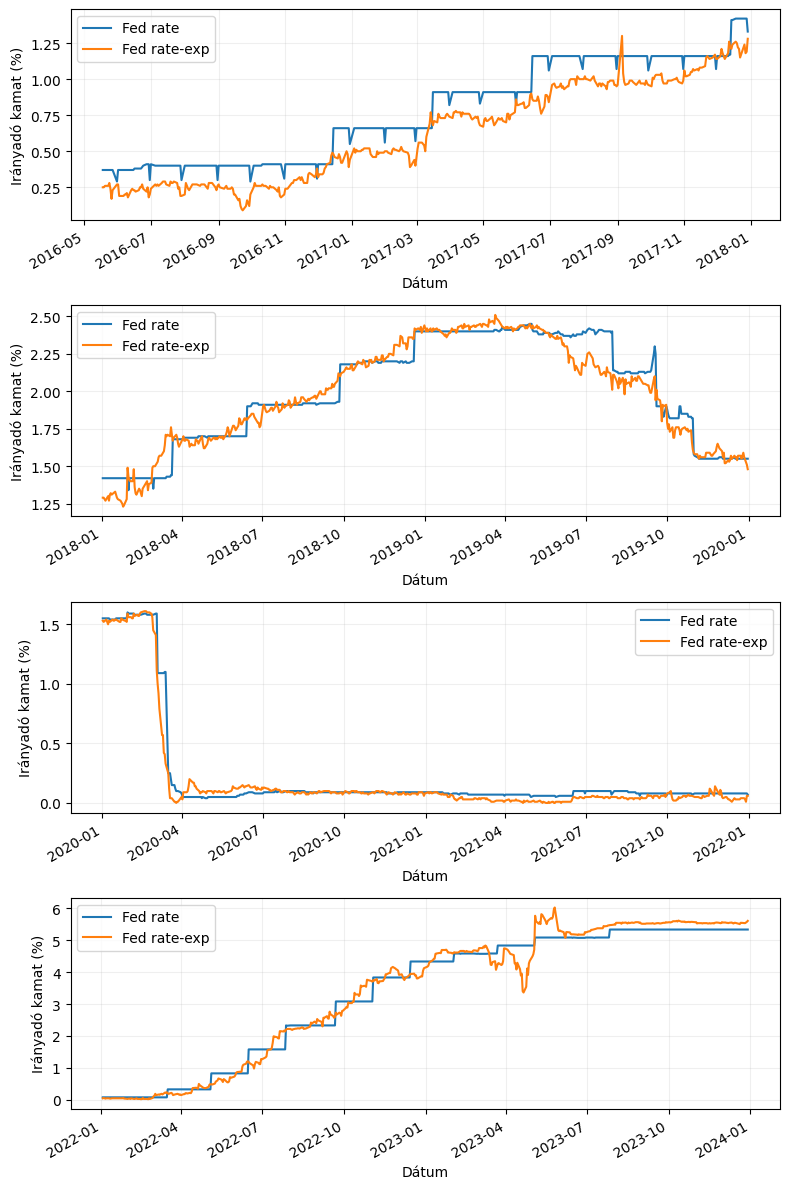

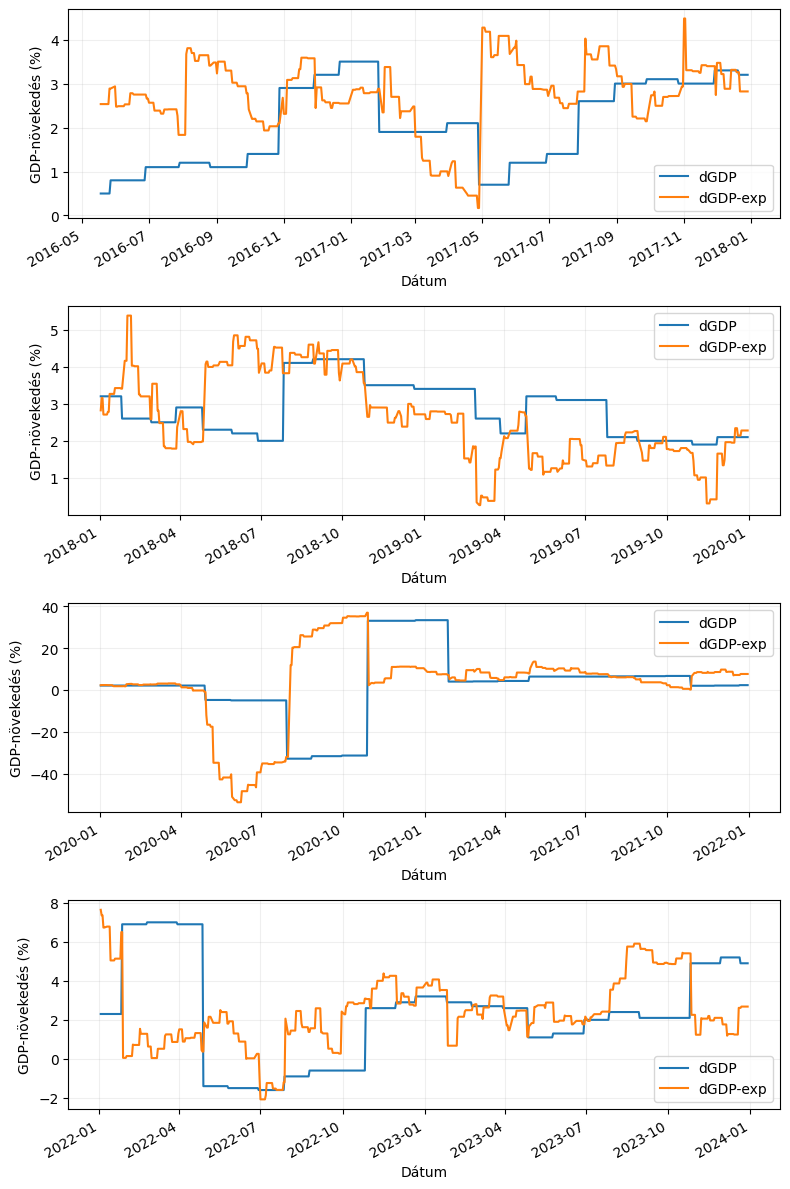

In [43]:
# Listák a generáláshoz: (Oszlopnevek, Tengely felirat, Fájlnév)
mutatok = [
    (['CPI', 'CPI-exp'], 'Havi infláció (%)', 'FRED_inflacio_4_abra.pdf'),
    (['Fed rate', 'Fed rate-exp'], 'Irányadó kamat (%)', 'FRED_kamat_4_abra.pdf'),
    (['dGDP', 'dGDP-exp'], 'GDP-növekedés (%)', 'FRED_gdp_4_abra.pdf')
]

years = list(range(2016, 2024, 2))

# Végigmegyünk a 3 faktoron
for cols, ylabel, filename in mutatok:
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 12))

    for i, year in enumerate(years):
        ax = axes[i]
        # Adatok szűrése és kirajzolása
        combined_df[cols].loc[f'{year}-01-01':f'{year+1}-12-31'].plot(ax=ax)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Dátum')

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

Korrelációs mátrix

In [44]:
corr_combined = combined_df[tickers].corr()
display(corr_combined)
corr_combined.to_latex('FRED_tickers_corr.tex',float_format="%.3f") # teljes időszaki korrelacio

data = combined_df[['SPY','TLT','GLD','VNQ','UUP','CPI','Fed rate','dGDP']]
factors = combined_df[['CPI-exp','Fed rate-exp','dGDP-exp','CPI-var','Fed rate-var','dGDP-var']]

# Korrelációs mátrixok egy adott időszakra:
data[['CPI','Fed rate','dGDP']].loc['2018-01-01':'2018-12-31'].corr().to_latex('FRED_actuals_ev_corr.tex',float_format="%.3f")
data.loc['2018-01-01':'2018-12-31'].corr().loc[['CPI','Fed rate','dGDP'],['SPY','TLT','GLD','VNQ','UUP']].to_latex('FRED_sec_actuals_ev_corr.tex',float_format="%.3f")
combined_df.loc['2018-01-01':'2018-12-31'].corr().loc[['CPI-exp','Fed rate-exp','dGDP-exp'],['SPY','TLT','GLD','VNQ','UUP']].to_latex('FRED_sec_expectations_ev_corr.tex',float_format="%.3f")

,SPY,TLT,GLD,VNQ,UUP
SPY,1.000000,-0.155257,0.069366,0.728013,-0.115582
TLT,-0.155257,1.000000,0.276103,0.039303,-0.223717
GLD,0.069366,0.276103,1.000000,0.140054,-0.448423
VNQ,0.728013,0.039303,0.140054,1.000000,-0.147323
UUP,-0.115582,-0.223717,-0.448423,-0.147323,1.000000


# MVO

In [45]:
names_secu = ['SPY','TLT','GLD','VNQ','UUP']
names_fact = ['CPI','Fed rate','dGDP']
names_all = ['SPY','TLT','GLD','VNQ','UUP','CPI','Fed rate','dGDP']

names_exp = ['CPI-exp','Fed rate-exp','dGDP-exp']
names_exp_var = ['CPI-var','Fed rate-var','dGDP-var']

returns = combined_df[names_all]
factors = combined_df[['CPI-exp','Fed rate-exp','dGDP-exp','CPI-var','Fed rate-var','dGDP-var']]

display(returns)

,SPY,TLT,GLD,VNQ,UUP,CPI,Fed rate,dGDP
Date,,,,,,,,
2016-05-18,0.000293,-0.014236,-0.017346,-0.015666,0.006945,0.407700,0.37,0.5
2016-05-19,-0.003465,0.004325,-0.001915,-0.011177,0.001623,0.407700,0.37,0.5
2016-05-20,0.006317,0.000769,-0.001335,0.007986,0.000000,0.407700,0.37,0.5
2016-05-23,-0.001363,0.002228,-0.002840,0.000122,-0.000405,0.407700,0.37,0.5
2016-05-24,0.012962,-0.004447,-0.017341,0.012431,0.003242,0.407700,0.37,0.5
...,...,...,...,...,...,...,...,...
2026-01-23,0.000363,0.002737,0.013745,0.001992,-0.008840,0.307355,3.64,4.4
2026-01-26,0.005078,0.004776,0.014629,-0.001325,-0.004831,0.307355,3.64,4.4
2026-01-27,0.003984,-0.006225,0.024532,-0.000332,-0.011576,0.307355,3.64,4.4


In [46]:
b_days = 252
Delta_t_mean = b_days
Delta_t_var  = int(b_days/2)
t_start = b_days # itt kezdjük
sigma_0 = 0.05 # 5%
sigma2 = sigma_0**2 / b_days

c_TR = 2e-4 # tranzakciós költség az érték arányában

# Bayes
update = True # True -> frissítés, False -> korrekció

In [47]:
s = len(tickers)
k = len(names_exp)
n = len(names_all)

print(f"s = {s}, k = {k}, n = {n}")
print(f"starting from {returns.index[t_start]}")

# Számolás
def calculate(isMBL, useCPI, useFedrate, usedGDP, isPV, useTR):

  all_dates = []
  all_weights = []

  w0 = np.zeros(s) # kezdetben nincsenek értékpapírjaink

  for t in range(t_start,len(returns)):
    t_date = returns.index[t]

    if isMBL == 1:
      ####################################
      # Makrofactor-Black-Litterman-modell használatával

      # Vetítő mátrix
      P = np.zeros((k, n))

      P[0, returns.columns.get_loc('CPI')]     = useCPI
      P[1, returns.columns.get_loc('Fed rate')] = useFedrate
      P[2, returns.columns.get_loc('dGDP')]     = usedGDP

      # Perfect view (tökéletes előrelátás) vagy sem?
      if isPV == 1:
        q = returns.loc[t_date, ['CPI', 'Fed rate', 'dGDP']].values
      else:
        q = factors.loc[t_date, ['CPI-exp', 'Fed rate-exp', 'dGDP-exp']].values

      #
      Pi    = returns[names_all].iloc[t-Delta_t_mean:t].mean().values
      Sigma = returns[names_all].iloc[t-Delta_t_var:t].cov().values

      #
      variances = factors.loc[t_date, ['CPI-var', 'Fed rate-var', 'dGDP-var']].values
      variances[variances == 0] = 0.1**2 # legalább 0.1% szórás, hogy az Omega invertálható legyen
      Omega = np.diag(variances)

      if update:
        # Bayes-i frissítés
        V = inv (inv(Sigma)      + (P.T @ inv(Omega) @ P))
        m = V @ (inv(Sigma) @ Pi + (P.T @ inv(Omega) @ q))
      else:
        # Bayes-i korrekció
        V = Sigma + inv(inv(Sigma) + P.T @ inv(Omega) @ P)
        m = Pi + Sigma @ P.T @ inv(P @ Sigma @ P.T + Omega) @ (q - P @ Pi)

      # Értékpapírok megtartása
      m_s = m[:s]
      V_s = V[:s, :s]
    else:
      ####################################
      # Markowitz-féle modell szerint (MVO)
      m_s = returns[names_secu].iloc[t-Delta_t_mean:t].mean().values
      V_s = returns[names_secu].iloc[t-Delta_t_var :t].cov().values

    # Optimalizálás
    w = cp.Variable(s) # súlyvektor
    risk = cp.quad_form(w, V_s) / 2 # kockázat függvény

    # Tranzakciós költség
    if useTR == 0:
      ret = m_s.T @ w
    else:
      ret = m_s.T @ w - c_TR * cp.norm(w - w0, 1)

    prob = cp.Problem(cp.Maximize(ret), [risk <= sigma2, cp.sum(w) == 1, w >= 0])

    # Megoldás
    try:
      prob.solve(solver=cp.CLARABEL)
    except cp.SolverError as e:
      print (t_date, V_s, m_s, np.linalg.det(V_s))

    # Ha nincs megoldás, a kockázat plafont megnöveljük
    if prob.status == cp.INFEASIBLE:
      prob = cp.Problem(cp.Maximize(m_s.T @ w),
                          [risk <= sigma2*10, cp.sum(w) == 1, w >= 0])
      prob.solve()

    # Ellenőrizzük, hogy sikeres volt-e az optimalizáció
    if prob.status not in ["optimal", "optimal_inaccurate"] or w.value is None:
        # Ha nincs megoldás, egyenlő súlyokat adunk
        wv = np.ones(s) / s
    else:
        wv = w.value
        wv[wv < 0] = 0

    w0 = wv # az előző napi súly frissítése a következő napi körhoz
    all_weights.append(wv)
    all_dates.append(t_date)

  # Ciklus vége
  weights = pd.DataFrame(all_weights, index=all_dates, columns=names_secu)
  weights.index = pd.to_datetime(weights.index)

  return weights

s = 5, k = 3, n = 8
starting from 2017-05-18 00:00:00


In [48]:
# isMBL (int), useCPI(int), useFedrate(int), usedGDP (int), isPV (int), useTR (int)

# Tranzakciós költségek nélkül
print("calculating MVO")
mvo_weights = calculate(0,0,0,0,0,0)

print("calculating MBL Fed")
mb3_weights = calculate(1,1,1,0,0,0)

print("calculating MBL PV")
mbp_weights = calculate(1,1,1,0,1,0)

# Tranzakciós költségekkel
print("calculating MVO +TR")
mvo_TR_weights = calculate(0,0,0,0,0,1)

print("calculating MBL +TR")
mb3_TR_weights = calculate(1,1,1,0,0,1)


calculating MVO
calculating MBL Fed
calculating MBL PV
calculating MVO +TR
calculating MBL +TR


In [49]:
# MVO
mvo_returns = returns[tickers].loc[mvo_weights.index]
mvo_daily_returns = (mvo_weights * mvo_returns).sum(axis=1)

# MBL Fed
mb3_returns = returns[names_secu].loc[mb3_weights.index]
mb3_daily_returns = (mb3_weights * mb3_returns).sum(axis=1)

# MBL PV
mbp_returns = returns[names_secu].loc[mbp_weights.index]
mbp_daily_returns = (mbp_weights * mbp_returns).sum(axis=1)

# MVO +TR
mvo_TR_returns = returns[tickers].loc[mvo_TR_weights.index]
mvo_TR_daily_returns = (mvo_TR_weights * mvo_TR_returns).sum(axis=1)

# MBL Fed +TR
mb3_TR_returns = returns[names_secu].loc[mb3_TR_weights.index]
mb3_TR_daily_returns = (mb3_TR_weights * mb3_TR_returns).sum(axis=1)

In [50]:
# Benchmark hozam
benchmarks = mvo_returns[['TLT']]

# Összesítsük egy táblázatba az adatokat
performance_df = pd.DataFrame({
    'MVO': mvo_daily_returns,
    'MBL Fed': mb3_daily_returns,
    'MBL PV': mbp_daily_returns,
    'TLT': benchmarks['TLT']
    })

performance_TR_df = pd.DataFrame({
    'MVO': mvo_daily_returns,
    'MBL Fed': mb3_daily_returns,
    'MVO +TR': mvo_TR_daily_returns,
    'MBL Fed +TR': mb3_TR_daily_returns,
    'TLT': benchmarks['TLT']
    })

metrics = {}
for col in performance_df.columns:
    # Annualized Return (Geometriai)
    total_ret = (1 + performance_df[col]).prod()
    n_days = len(performance_df)
    ann_ret = (total_ret ** (b_days / n_days)) - 1

    # Annualized Volatility
    ann_vol = performance_df[col].std() * np.sqrt(b_days)

    # Sharpe Ratio (Rf = CDI átlagos évesített hozama)
    cdi_ann = ((1 + performance_df['TLT']).prod() ** (b_days / n_days)) - 1
    sharpe = (ann_ret - cdi_ann) / ann_vol if col != 'TLT' else 0

    # Maximum Drawdown
    cum_ret = (1 + performance_df[col]).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    max_dd = drawdown.min()

    metrics[col] = [ann_ret * 100, ann_vol * 100, - max_dd * 100, sharpe]

# Táblázat megjelenítése
table_3 = pd.DataFrame(metrics,
                       index=['Éves hozam', 'Éves $\sigma$',
                              'Max. visszaesés', 'Sharpe-ráta']).T
print("--- Table 3: Performance analysis ---")
formats = {col: "{:.2f}\%" for col in table_3.columns[:-1]}
formats[table_3.columns[-1]] = "{:.2f}"
table_3.style.format(formats).to_latex("FRED_Table3.tex",
                                       column_format="lcccc", hrules=True)

display(table_3)

--- Table 3: Performance analysis ---


<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\%'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_4627/648940226.py:44: SyntaxWarning: invalid escape sequence '\s'
  index=['Éves hozam', 'Éves $\sigma$',
/tmp/ipykernel_4627/648940226.py:47: SyntaxWarning: invalid escape sequence '\%'
  formats = {col: "{:.2f}\%" for col in table_3.columns[:-1]}


,Éves hozam,Éves $\sigma$,Max. visszaesés,Sharpe-ráta
MVO,9.776437,8.532671,13.670715,1.284574
MBL Fed,9.958645,7.860316,10.230989,1.417634
MBL PV,8.882953,7.746604,9.482312,1.299584
TLT,-1.184409,15.323161,48.351131,0.000000


--- Figure 4: Cumulative returns ---


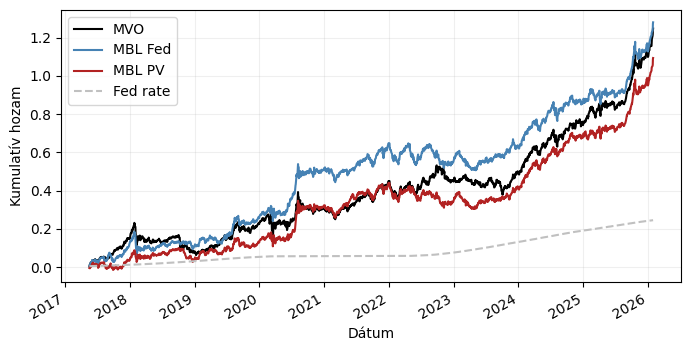

--- Figure 4 TR: Cumulative returns ---


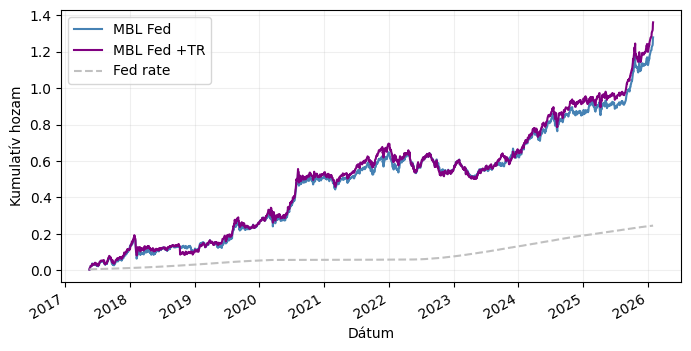

--- Figure 5: Allocations and cumulative return for MVO ---


<Figure size 640x480 with 0 Axes>

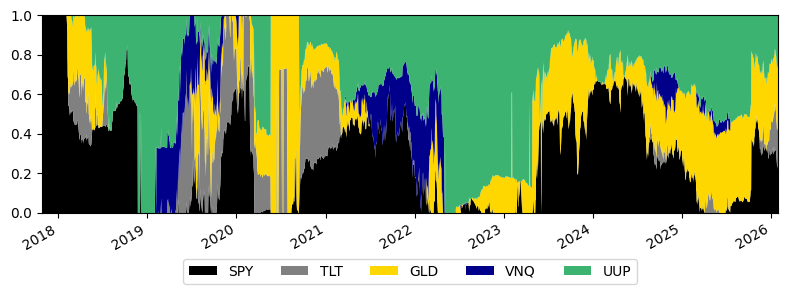

--- Figure 6: Allocations and cumulative return for MBL ---


<Figure size 640x480 with 0 Axes>

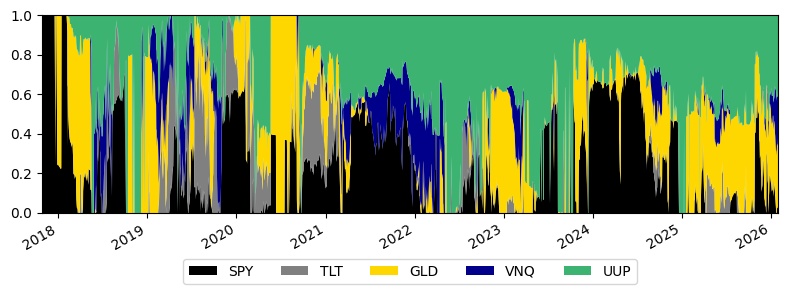

In [51]:
# Kumulatív növekedés számítása
cumulative_growth = (1 + performance_df).cumprod() - 1
cumulative_growth['Fed rate'] = (1 + returns['Fed rate'] /100 /b_days).cumprod() - 1

cumulative_growth_TR = (1 + performance_TR_df).cumprod() - 1
cumulative_growth_TR['Fed rate'] = (1 + returns['Fed rate'] /100 /b_days).cumprod() - 1

print("--- Figure 4: Cumulative returns ---")
plt.figure(figsize=(8,4))
cumulative_growth['MVO'].plot(color = 'black', linestyle = '-')
cumulative_growth['MBL Fed'].plot(color = 'steelblue', linestyle = '-')
cumulative_growth['MBL PV'].plot(color = 'firebrick', linestyle = '-')
cumulative_growth['Fed rate'].plot(color = 'silver', linestyle = '--')
plt.xlabel("Dátum")
plt.ylabel("Kumulatív hozam")
plt.legend(loc='upper left')
plt.savefig('FRED_opt_kumulativ_hozamok.pdf', bbox_inches='tight')
plt.show()
plt.close()

print("--- Figure 4 TR: Cumulative returns ---")
plt.figure(figsize=(8,4))
cumulative_growth_TR['MBL Fed'].plot(color = 'steelblue', linestyle = '-')
cumulative_growth_TR['MBL Fed +TR'].plot(color = 'purple', linestyle = '-')
cumulative_growth_TR['Fed rate'].plot(color = 'silver', linestyle = '--')
plt.xlabel("Dátum")
plt.ylabel("Kumulatív hozam")
plt.legend(loc='upper left')
plt.savefig('FRED_TR_opt_kumulativ_hozamok.pdf', bbox_inches='tight')
plt.show()
plt.close()

print("--- Figure 5: Allocations and cumulative return for MVO ---")
plt.figure()
mvo_weights.plot.area(figsize=(8,3), linewidth=0,
                      color = szinek)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)
plt.tight_layout()
plt.xlim('2017-10-25','2026-01-30')
plt.ylim(0,1)
plt.grid(False)
plt.savefig('FRED_opt_mvo_eszkozallokacio.pdf', bbox_inches='tight')
plt.show()
plt.close()

print("--- Figure 6: Allocations and cumulative return for MBL ---")
plt.figure()
mb3_weights.plot.area(figsize=(8,3), linewidth=0,
                      color = szinek)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)
plt.tight_layout()
plt.xlim('2017-10-25','2026-01-30')
plt.ylim(0,1)
plt.grid(False)
plt.savefig('FRED_opt_mbl_eszkozallokacio.pdf', bbox_inches='tight')
plt.show()
plt.close()

Ábrák és táblázatok mentése

In [52]:
import zipfile
import glob

# Összegyűjtjük az összes PDF és TEX fájlt a jelenlegi mappából
pdf_files = glob.glob("*.pdf")
tex_files = glob.glob("*.tex")
all_files = pdf_files + tex_files

# Létrehozzuk a ZIP archívumot
with zipfile.ZipFile('FRED_abrak_tablazatok.zip', 'w') as zipf:
  for file in all_files:
    zipf.write(file)